In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

In [37]:
df = pd.read_csv("dataset raw+feature.csv")

df.head()

,Timestamp,Open,High,Low,Close,Volume,Ticker,return,rolling_mean_20,rolling_volatility_20,high_low_spread,momentum,volume_change,price_range_ratio,volume_zscore,return_zscore
0,6/18/2024,186.559998,187.199997,182.369995,184.860001,68982300,TSLA,-0.013764,178.2750,0.028392,4.830002,-2.580002,0.920365,0.026128,-0.296565,-0.595251
1,6/20/2024,184.679993,185.210007,179.660004,181.570007,55893100,TSLA,-0.017797,178.0235,0.024464,5.550003,-3.289993,0.776484,0.030567,-0.886551,-0.683191
2,6/21/2024,182.300003,183.949997,180.690002,183.009995,61937300,TSLA,0.007931,178.1685,0.023199,3.259995,1.439987,0.876510,0.017813,-0.488730,0.296512
3,6/24/2024,184.970001,188.800003,182.550003,182.580002,61992100,TSLA,-0.002350,178.6105,0.021590,6.250000,-0.429993,0.883527,0.034232,-0.455138,-0.234013
4,6/25/2024,184.399994,187.970001,182.009995,187.350006,62905700,TSLA,0.026126,179.0160,0.021232,5.960007,4.770004,0.898263,0.031812,-0.395785,1.116196


In [38]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (482, 16)

Columns:
Index(['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker',
       'return', 'rolling_mean_20', 'rolling_volatility_20', 'high_low_spread',
       'momentum', 'volume_change', 'price_range_ratio', 'volume_zscore',
       'return_zscore'],
      dtype='object')

First rows:
   Timestamp        Open        High         Low       Close    Volume Ticker  \
0  6/18/2024  186.559998  187.199997  182.369995  184.860001  68982300   TSLA   
1  6/20/2024  184.679993  185.210007  179.660004  181.570007  55893100   TSLA   
2  6/21/2024  182.300003  183.949997  180.690002  183.009995  61937300   TSLA   
3  6/24/2024  184.970001  188.800003  182.550003  182.580002  61992100   TSLA   
4  6/25/2024  184.399994  187.970001  182.009995  187.350006  62905700   TSLA   

     return  rolling_mean_20  rolling_volatility_20  high_low_spread  \
0 -0.013764         178.2750               0.028392         4.830002   
1 -0.017797         178.0235               0.024464     

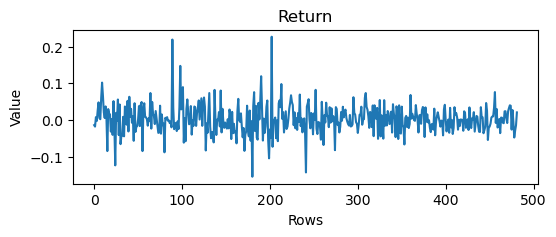

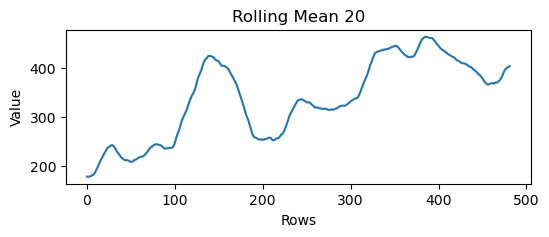

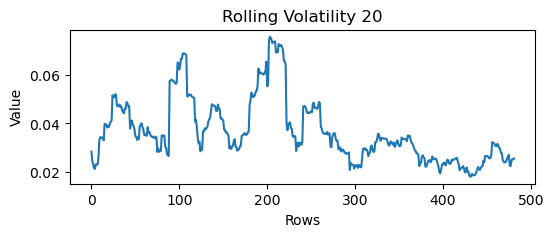

In [39]:
plt.figure(figsize=(6,2))
plt.plot(df['return'])
plt.title("Return")
plt.xlabel("Rows")
plt.ylabel("Value")
plt.show()

plt.figure(figsize=(6,2))
plt.plot(df['rolling_mean_20'])
plt.title("Rolling Mean 20")
plt.xlabel("Rows")
plt.ylabel("Value")
plt.show()

plt.figure(figsize=(6,2))
plt.plot(df['rolling_volatility_20'])
plt.title("Rolling Volatility 20")
plt.xlabel("Rows")
plt.ylabel("Value")
plt.show()

In [40]:
X = df.copy()# Select only feature columns for Isolation Forest

feature_columns = [
    'return',
    'rolling_mean_20',
    'rolling_volatility_20',
    'high_low_spread',
    'momentum',
    'volume_change',
    'price_range_ratio',
    'volume_zscore',
    'return_zscore'
]

X = df[feature_columns].copy()

In [41]:
X.describe()

,return,rolling_mean_20,rolling_volatility_20,high_low_spread,momentum,volume_change,price_range_ratio,volume_zscore,return_zscore
count,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000
mean,0.002379,337.013937,0.036543,14.633672,0.466992,0.998929,0.043891,-0.032810,-0.009276
std,0.038800,80.951803,0.013131,7.285324,12.209812,0.306275,0.022457,1.038798,0.972294
min,-0.154262,178.023500,0.018016,2.960007,-47.349976,0.355424,0.013580,-2.320494,-3.090933
25%,-0.019692,256.498501,0.026882,9.585007,-6.677490,0.795222,0.030001,-0.801961,-0.606964
50%,0.001327,335.520250,0.033630,13.134995,0.430008,0.934227,0.038666,-0.253184,-0.023062
75%,0.024609,410.961748,0.044206,17.524990,8.577515,1.134599,0.052357,0.559623,0.620810
max,0.226900,464.700502,0.075753,61.529999,50.340012,2.568759,0.186664,3.884648,3.766884


In [53]:
# Create scaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

In [54]:
X_scaled.describe()

,return,rolling_mean_20,rolling_volatility_20,high_low_spread,momentum,volume_change,price_range_ratio,volume_zscore,return_zscore
count,4.820000e+02,4.820000e+02,4.820000e+02,4.820000e+02,4.820000e+02,4.820000e+02,4.820000e+02,4.820000e+02,4.820000e+02
mean,-5.528081e-18,3.537972e-16,-2.948310e-16,-3.501118e-16,-2.764041e-17,-1.916402e-16,5.896620e-17,-7.370775e-18,1.013482e-17
std,1.001039e+00,1.001039e+00,1.001039e+00,1.001039e+00,1.001039e+00,1.001039e+00,1.001039e+00,1.001039e+00,1.001039e+00
min,-4.041312e+00,-1.966054e+00,-1.412454e+00,-1.604018e+00,-3.920343e+00,-2.103253e+00,-1.351135e+00,-2.204530e+00,-3.172764e+00
25%,-5.694494e-01,-9.956429e-01,-7.365314e-01,-6.937111e-01,-5.857506e-01,-6.658033e-01,-6.191393e-01,-7.411935e-01,-6.153586e-01
50%,-2.714415e-02,-1.847073e-02,-2.220201e-01,-2.059255e-01,-3.032167e-03,-2.114748e-01,-2.329037e-01,-2.123639e-01,-1.419386e-02
75%,5.735104e-01,9.144285e-01,5.842694e-01,3.972812e-01,6.649529e-01,4.434269e-01,3.773553e-01,5.708984e-01,6.487139e-01
max,5.792574e+00,1.578955e+00,2.989296e+00,6.443784e+00,4.088911e+00,5.130881e+00,6.364176e+00,3.775064e+00,3.887799e+00


In [55]:
# Create Isolation Forest model
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Train model
model.fit(X_scaled)

print("training completed")

training completed


In [56]:
# Replace spreadsheet errors with missing values
X = X.replace('#VALUE!', np.nan)

# Convert all columns to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Remove rows with missing values
X = X.dropna()

# Check remaining missing values
print(X.isnull().sum())

return                   0
rolling_mean_20          0
rolling_volatility_20    0
high_low_spread          0
momentum                 0
volume_change            0
price_range_ratio        0
volume_zscore            0
return_zscore            0
dtype: int64


In [61]:
# Recreate predictions and scores
predictions = model.predict(X_scaled)
scores = model.decision_function(X_scaled)

# Add both columns into X
X['anomaly'] = predictions
X['anomaly_score'] = scores

# Transfer back into original dataframe
df.loc[X.index, 'anomaly'] = predictions
df.loc[X.index, 'anomaly_score'] = scores

# Verify
X[['anomaly', 'anomaly_score']].head()

,anomaly,anomaly_score
0,1,0.117959
1,1,0.116478
2,1,0.093460
3,1,0.124808
4,1,0.097770


In [62]:
# Show only anomaly rows

anomaly_rows = X[X['anomaly'] == -1]

anomaly_rows.head(10)

,return,rolling_mean_20,rolling_volatility_20,high_low_spread,momentum,volume_change,price_range_ratio,volume_zscore,return_zscore,anomaly_score,anomaly
8,0.060542,183.602000,0.025954,12.379990,11.979996,1.761347,0.058992,2.507405,2.002884,-0.010830,-1
9,0.101973,186.350500,0.032888,13.240005,21.399994,2.445052,0.057252,3.289938,2.670032,-0.088552,-1
15,-0.084441,209.742000,0.039809,31.350006,-22.230011,1.922632,0.130067,2.153528,-2.577327,-0.073108,-1
24,-0.123346,237.924999,0.051608,11.279999,-30.389999,1.235994,0.052225,0.826798,-2.553428,-0.018468,-1
55,-0.084459,212.725002,0.038918,23.090012,-19.440002,1.466133,0.109572,2.185624,-2.263505,-0.024614,-1
80,-0.087825,244.117500,0.035075,8.959991,-20.970001,1.754285,0.041139,3.102712,-2.441334,-0.036742,-1
89,0.219190,235.771001,0.057485,19.470001,46.830017,2.568759,0.074747,3.367002,3.766884,-0.136417,-1
98,0.147510,239.979001,0.065100,13.970001,37.089996,1.907648,0.048418,1.707175,2.098868,-0.061377,-1
100,0.081877,248.057001,0.062226,31.049988,24.309998,2.239713,0.096663,2.175444,0.973731,-0.057500,-1
101,0.089596,254.599000,0.063934,22.640015,28.779999,2.156009,0.064686,1.930364,1.003279,-0.022268,-1


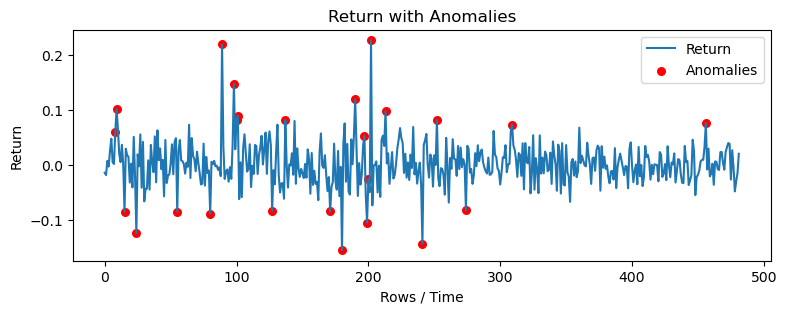

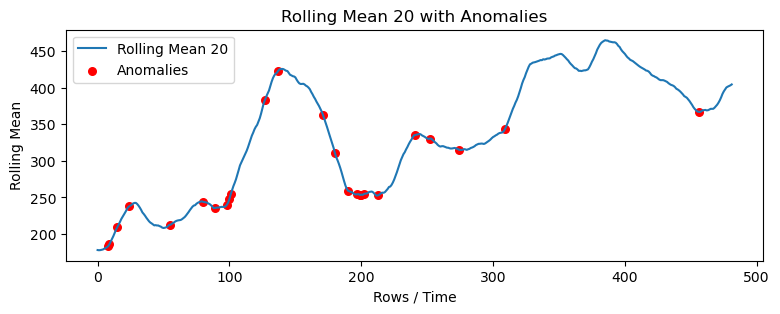

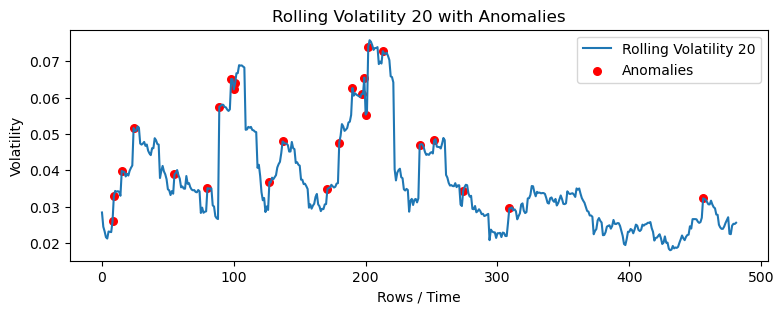

In [63]:
# Return graph
plt.figure(figsize=(9,3))
plt.plot(df['return'], label='Return')

plt.scatter(
    df[df['anomaly']==-1].index,
    df[df['anomaly']==-1]['return'],
    color='red',
    s=30,
    label='Anomalies'
)

plt.title("Return with Anomalies")
plt.xlabel("Rows / Time")
plt.ylabel("Return")
plt.legend()
plt.show()


# Rolling Mean graph
plt.figure(figsize=(9,3))
plt.plot(df['rolling_mean_20'], label='Rolling Mean 20')

plt.scatter(
    df[df['anomaly']==-1].index,
    df[df['anomaly']==-1]['rolling_mean_20'],
    color='red',
    s=30,
    label='Anomalies'
)

plt.title("Rolling Mean 20 with Anomalies")
plt.xlabel("Rows / Time")
plt.ylabel("Rolling Mean")
plt.legend()
plt.show()


# Rolling Volatility graph
plt.figure(figsize=(9,3))
plt.plot(df['rolling_volatility_20'], label='Rolling Volatility 20')

plt.scatter(
    df[df['anomaly']==-1].index,
    df[df['anomaly']==-1]['rolling_volatility_20'],
    color='red',
    s=30,
    label='Anomalies'
)

plt.title("Rolling Volatility 20 with Anomalies")
plt.xlabel("Rows / Time")
plt.ylabel("Volatility")
plt.legend()
plt.show()

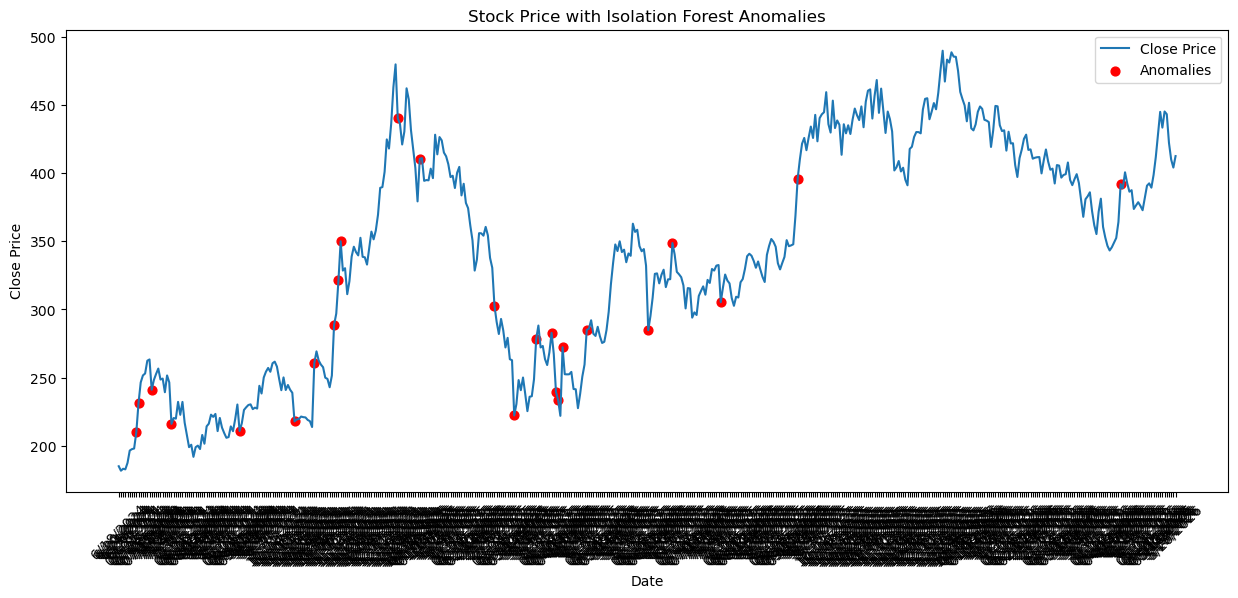

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    df['Timestamp'],
    df['Close'],
    label='Close Price'
)

plt.scatter(
    df[df['anomaly']==-1]['Timestamp'],
    df[df['anomaly']==-1]['Close'],
    color='red',
    s=40,
    label='Anomalies'
)

plt.title("Stock Price with Isolation Forest Anomalies")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.xticks(rotation=45)

plt.legend()
plt.show()